# Natural Language Processing

## Предварительная обработка текстов

### Задача классификации твитов на тональность

In [2]:
# скачаем куски датасета
!wget https://raw.githubusercontent.com/maryszmary/netology_nlp_2021/master/sem1/tweets_sentiment.csv

--2026-02-21 12:55:41--  https://raw.githubusercontent.com/maryszmary/netology_nlp_2021/master/sem1/tweets_sentiment.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 32795904 (31M) [text/plain]
Saving to: ‘tweets_sentiment.csv’

tweets_sentiment.cs 100%[===================>]  31.28M  21.7MB/s    in 1.4s    

2026-02-21 12:55:43 (21.7 MB/s) - ‘tweets_sentiment.csv’ saved [32795904/32795904]



In [64]:
from string import punctuation
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from nltk import ngrams
from nltk import tokenize
from nltk.tokenize import word_tokenize, toktok

Визуализируем датасет

In [4]:
df = pd.read_csv('tweets_sentiment.csv')
df.head()

,text,label
0,мыс на меня обиделась:(\nя ей даже ничего не с...,negative
1,"аааааааааааааааааааа,не хочу на работу :(",negative
2,"У меня какой-то особенный вид ушей! :D, некото...",positive
3,@simonovkon он неплохой человек в жизни. Я ра...,negative
4,"RT @Darina_Lo: Домааааа\nЕхали на такси, пели ...",positive


Делим датасет на обучающую и тестовую выборку

In [5]:
x_train, x_test, y_train, y_test = train_test_split(df.text, df.label)

In [6]:
print(df.shape)
print(x_train.shape)
print(x_test.shape)

(226834, 2)
(170125,)
(56709,)


### Baseline: Классификация необработанных n-грамм
### Векторизаторы

In [8]:
df['text'].head().tolist()

['мыс на меня обиделась:(\nя ей даже ничего не сделала:(',
 'аааааааааааааааааааа,не хочу на работу :(',
 'У меня какой-то особенный вид ушей! :D, некоторые вакуумные наушники в моих ушах просто не держатся!',
 '@simonovkon  он неплохой человек в жизни. Я работала в шоу-бизе, со многими знакома. Встречаются очень хорошие люди. И не очень(((',
 'RT @Darina_Lo: Домааааа\nЕхали на такси, пели песни, отдыхали.\nКричали на улице:)\nМы настоящяя семья)']

#### CountVectorizer

- Строит для каждого документа (каждой пришедшей ему строки) вектор размерности `n`, где `n` - количество слов или n-грамм во всем корпусе
- Заполняет каждый i-й элемент количеством вхождений слова в данный документ

In [32]:
# Инициализируем класс CountVectirizer
vec = CountVectorizer(ngram_range=(1, 1)) # униграммы
# Обучаем век
bow = vec.fit_transform(x_train)

In [33]:
bow.shape

(170125, 243893)

In [34]:
list(vec.vocabulary_.items())[:20]

[('шоколадке', 239555),
 ('нужно', 169645),
 ('привести', 193318),
 ('какую', 142853),
 ('нибудь', 168127),
 ('хрень', 234697),
 ('только', 222531),
 ('вопрос', 114522),
 ('bata_good', 16706),
 ('хых', 235276),
 ('меня', 157723),
 ('отсылали', 177329),
 ('какой', 142826),
 ('то', 222216),
 ('художественный', 234907),
 ('магазин', 155123),
 ('там', 219945),
 ('подешевле', 185065),
 ('вроде', 115361),
 ('должно', 127439)]

In [25]:
vec_bi = CountVectorizer(ngram_range=(2, 2))
bow_bi = vec_bi.fit_transform(x_train)
bow_bi.shape

(170125, 1003989)

In [26]:
list(vec_bi.vocabulary_.items())[:20]

[('шоколадке нужно', 984048),
 ('нужно привести', 601652),
 ('привести какую', 718949),
 ('какую нибудь', 423644),
 ('нибудь хрень', 584316),
 ('хрень только', 954522),
 ('только вопрос', 889408),
 ('вопрос какую', 249856),
 ('bata_good хых', 25212),
 ('хых меня', 956188),
 ('меня отсылали', 495736),
 ('отсылали какой', 640322),
 ('какой то', 423422),
 ('то художественный', 884892),
 ('художественный магазин', 954924),
 ('магазин там', 482075),
 ('там подешевле', 863148),
 ('подешевле вроде', 676025),
 ('вроде должно', 256191),
 ('должно быть', 329452)]

In [27]:
len(list(vec_bi.vocabulary_.items()))

1003989

#### Создание n-грамм с помощью библиотеки nltk

In [28]:
sent = 'Harry Potter and the Methods of Rationality'.split()
list(ngrams(sent,1)) # униграммы

[('Harry',),
 ('Potter',),
 ('and',),
 ('the',),
 ('Methods',),
 ('of',),
 ('Rationality',)]

In [29]:
sent

['Harry', 'Potter', 'and', 'the', 'Methods', 'of', 'Rationality']

In [30]:
list(ngrams(sent, 2)) # биграммы

[('Harry', 'Potter'),
 ('Potter', 'and'),
 ('and', 'the'),
 ('the', 'Methods'),
 ('Methods', 'of'),
 ('of', 'Rationality')]

In [31]:
list(ngrams(sent, 3)) # триграммы

[('Harry', 'Potter', 'and'),
 ('Potter', 'and', 'the'),
 ('and', 'the', 'Methods'),
 ('the', 'Methods', 'of'),
 ('Methods', 'of', 'Rationality')]

In [35]:
# Обучение модели логистической регрессии:
clf = LogisticRegression(random_state=42, solver='liblinear')
clf.fit(bow, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [36]:
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

              precision    recall  f1-score   support

    negative       0.77      0.76      0.76     28306
    positive       0.77      0.77      0.77     28403

    accuracy                           0.77     56709
   macro avg       0.77      0.77      0.77     56709
weighted avg       0.77      0.77      0.77     56709



In [37]:
# Обучение модели на триграммах:
vec = CountVectorizer(ngram_range=(3, 3))
bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42)
clf.fit(bow, y_train)
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

              precision    recall  f1-score   support

    negative       0.47      0.72      0.57     18210
    positive       0.82      0.61      0.70     38499

    accuracy                           0.65     56709
   macro avg       0.65      0.67      0.63     56709
weighted avg       0.71      0.65      0.66     56709



#### Эксперименты с CountVectorizer

In [38]:
vec_mini = CountVectorizer()

In [39]:
corpus = [
    'в москве сегодня снег',
    'в москве холодно и сыро',
    'снег это хорошо но холодно',
]

Метод `fit` - выстраивание всех слов по алфавиту и запоминане позиции каждого из слов

In [40]:
vec_mini.fit(corpus)

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'


В результате получается словарь

In [41]:
vec_mini.vocabulary_

{'москве': 0,
 'сегодня': 2,
 'снег': 3,
 'холодно': 5,
 'сыро': 4,
 'это': 7,
 'хорошо': 6,
 'но': 1}

Метод `transform` превращает каждое слово в `one-hot` вектор

In [42]:
matrix = vec_mini.transform(corpus)
matrix

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 11 stored elements and shape (3, 8)>

В результате получается спарс-матрица.

Переведем ее в `dense` формат. Получилась матрица, каждый из векторов в которой представляет собой сумму `one-hot` векторов влов текста

In [43]:
matrix.todense()

matrix([[1, 0, 1, 1, 0, 0, 0, 0],
        [1, 0, 0, 0, 1, 1, 0, 0],
        [0, 1, 0, 1, 0, 1, 1, 1]])

Если с помощью этого вектроизатора попробовать преобразовать другой текст. 

Векторайзер будет игнорировать все слова из нового текста, которые не входят в созданный ранее словарь.

In [45]:
matrix = vec_mini.transform(['в москве живут котики'])
matrix.todense()

matrix([[1, 0, 0, 0, 0, 0, 0, 0]])

#### Tfidf Vectorizer

Работает схожим образом. Только в дополнение к сложнению `one-hot` векторов слов в вектор токена, он домножает вектор каждого токена на значение TfIdf этого токена

In [46]:
vec = TfidfVectorizer()
bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42, solver='liblinear')
clf.fit(bow, y_train)
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

              precision    recall  f1-score   support

    negative       0.73      0.77      0.75     26858
    positive       0.78      0.75      0.77     29851

    accuracy                           0.76     56709
   macro avg       0.76      0.76      0.76     56709
weighted avg       0.76      0.76      0.76     56709



### Токенизация

In [47]:
# split по пробелу
print(df['text'].iloc[0].split())

['мыс', 'на', 'меня', 'обиделась:(', 'я', 'ей', 'даже', 'ничего', 'не', 'сделала:(']


In [48]:
vec.get_feature_names_out()[20:40]

array(['004anna', '004hafarf4', '005', '0060', '007', '0080',
       '008ge0nygh', '008novublr', '009', '009_panda', '00_anita_00',
       '00_elenka', '00_kalashnikova', '00_katusha', '00_orekhova',
       '00c6a95bst', '00darya', '00ennqulcp', '00fedosova', '00gorbunova'],
      dtype=object)

#### Использование nltk.tokenize

In [49]:
example = 'Но не каждый хочет что-то исправлять:('
word_tokenize(example)

['Но', 'не', 'каждый', 'хочет', 'что-то', 'исправлять', ':', '(']

In [50]:
word_tokenize(df['text'].iloc[0])

['мыс',
 'на',
 'меня',
 'обиделась',
 ':',
 '(',
 'я',
 'ей',
 'даже',
 'ничего',
 'не',
 'сделала',
 ':',
 '(']

In [52]:
text = u'Is 9.5 or 525,600 my favorite number?'
word_tokenize(text)

['Is', '9.5', 'or', '525,600', 'my', 'favorite', 'number', '?']

In [53]:
dir(tokenize)[:16]

['BlanklineTokenizer',
 'LegalitySyllableTokenizer',
 'LineTokenizer',
 'MWETokenizer',
 'NLTKWordTokenizer',
 'PunktSentenceTokenizer',
 'PunktTokenizer',
 'RegexpTokenizer',
 'ReppTokenizer',
 'SExprTokenizer',
 'SpaceTokenizer',
 'StanfordSegmenter',
 'SyllableTokenizer',
 'TabTokenizer',
 'TextTilingTokenizer',
 'ToktokTokenizer']

In [65]:
toktok = toktok.ToktokTokenizer()
text = u'Is 9.5 or 525,600 my favorite number?'
print(toktok.tokenize(text))

['Is', '9.5', 'or', '525,600', 'my', 'favorite', 'number', '?']


Получение индексов начала и конца каждого токена

In [66]:
wh_tok = tokenize.WhitespaceTokenizer()
list(wh_tok.span_tokenize(example))

[(0, 2), (3, 5), (6, 12), (13, 18), (19, 25), (26, 38)]

### Самые частотные слова

In [67]:
# стандартная библиотека string
punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
corpus = [token for tweet in df.text for token in word_tokenize(tweet) if token not in punctuation]
print(len(corpus))
corpus[:10]

2870536


['мыс',
 'на',
 'меня',
 'обиделась',
 'я',
 'ей',
 'даже',
 'ничего',
 'не',
 'сделала']

In [74]:
tweets = [tweet for tweet in df.text]
tweets[:10]

['мыс на меня обиделась:(\nя ей даже ничего не сделала:(',
 'аааааааааааааааааааа,не хочу на работу :(',
 'У меня какой-то особенный вид ушей! :D, некоторые вакуумные наушники в моих ушах просто не держатся!',
 '@simonovkon  он неплохой человек в жизни. Я работала в шоу-бизе, со многими знакома. Встречаются очень хорошие люди. И не очень(((',
 'RT @Darina_Lo: Домааааа\nЕхали на такси, пели песни, отдыхали.\nКричали на улице:)\nМы настоящяя семья)',
 '@passkrinDObroTA это ужасно:( так страашно',
 'RT @miwisakovab: Не грустим за летом, скоро будет следующее)',
 'Лежим с молой в постели , помогаем ему выбирать машину !)',
 'Я ВАС НАЙДУ, ОТРЕЖУ ПАЛЬЦЫ И ЗАСТАВЛЮ СОЖРАТЬ, ЕСЛИ ЕЩЕ РАЗ ДОБАВИТЕ МЕНЯ В ОБЩУЮ БЕСЕДУ ВКОНТАКТЕ С КАКОЙ-ТО ЛЕВОЙ ХЕРНЕЙ! чмоки, лавки :*',
 '@larkagerasimova Контоев Артем) рост, вес и тд интересует ?)']

In [77]:
word_tokenize(tweets[0])

['мыс',
 'на',
 'меня',
 'обиделась',
 ':',
 '(',
 'я',
 'ей',
 'даже',
 'ничего',
 'не',
 'сделала',
 ':',
 '(']

In [82]:
tokens = [token for tweet in df.text for token in word_tokenize(tweet)]
tokens[:10]

['мыс', 'на', 'меня', 'обиделась', ':', '(', 'я', 'ей', 'даже', 'ничего']

In [85]:
# частотный словарь - метод Counter из стандатрной библиотеки collections
freq_dict = Counter(corpus)

freq_dict.most_common(20)

[('не', 69472),
 ('и', 55166),
 ('в', 52902),
 ('я', 52818),
 ('RT', 38070),
 ('на', 35759),
 ('http', 32998),
 ('что', 31541),
 ('с', 27217),
 ('а', 26860),
 ('...', 22363),
 ('меня', 20656),
 ('у', 18928),
 ('как', 18280),
 ('так', 16839),
 ('D', 16575),
 ('это', 16542),
 ('мне', 16337),
 ('все', 14763),
 ('ты', 13412)]

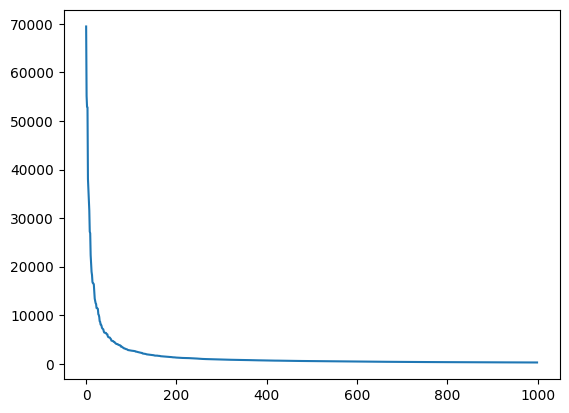

In [86]:
freqs = list(freq_dict.values())
freqs = sorted(freqs, reverse=True)

fig, ax = plt.subplots()
ax.plot(range(1000), freqs[:1000])
plt.show()

### Стоп-слова и пунктуация

In [87]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/andrew/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [88]:
from nltk.corpus import stopwords
print(stopwords.words('russian'))

['и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все', 'она', 'так', 'его', 'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за', 'бы', 'по', 'только', 'ее', 'мне', 'было', 'вот', 'от', 'меня', 'еще', 'нет', 'о', 'из', 'ему', 'теперь', 'когда', 'даже', 'ну', 'вдруг', 'ли', 'если', 'уже', 'или', 'ни', 'быть', 'был', 'него', 'до', 'вас', 'нибудь', 'опять', 'уж', 'вам', 'ведь', 'там', 'потом', 'себя', 'ничего', 'ей', 'может', 'они', 'тут', 'где', 'есть', 'надо', 'ней', 'для', 'мы', 'тебя', 'их', 'чем', 'была', 'сам', 'чтоб', 'без', 'будто', 'чего', 'раз', 'тоже', 'себе', 'под', 'будет', 'ж', 'тогда', 'кто', 'этот', 'того', 'потому', 'этого', 'какой', 'совсем', 'ним', 'здесь', 'этом', 'один', 'почти', 'мой', 'тем', 'чтобы', 'нее', 'сейчас', 'были', 'куда', 'зачем', 'всех', 'никогда', 'можно', 'при', 'наконец', 'два', 'об', 'другой', 'хоть', 'после', 'над', 'больше', 'тот', 'через', 'эти', 'нас', 'про', 'всего', 'них', 'какая', 'много', 'разве', 'три', 'эту', 'моя', 'впр

In [89]:
punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [91]:
noise = stopwords.words('russian') + list(punctuation)
noise

['и',
 'в',
 'во',
 'не',
 'что',
 'он',
 'на',
 'я',
 'с',
 'со',
 'как',
 'а',
 'то',
 'все',
 'она',
 'так',
 'его',
 'но',
 'да',
 'ты',
 'к',
 'у',
 'же',
 'вы',
 'за',
 'бы',
 'по',
 'только',
 'ее',
 'мне',
 'было',
 'вот',
 'от',
 'меня',
 'еще',
 'нет',
 'о',
 'из',
 'ему',
 'теперь',
 'когда',
 'даже',
 'ну',
 'вдруг',
 'ли',
 'если',
 'уже',
 'или',
 'ни',
 'быть',
 'был',
 'него',
 'до',
 'вас',
 'нибудь',
 'опять',
 'уж',
 'вам',
 'ведь',
 'там',
 'потом',
 'себя',
 'ничего',
 'ей',
 'может',
 'они',
 'тут',
 'где',
 'есть',
 'надо',
 'ней',
 'для',
 'мы',
 'тебя',
 'их',
 'чем',
 'была',
 'сам',
 'чтоб',
 'без',
 'будто',
 'чего',
 'раз',
 'тоже',
 'себе',
 'под',
 'будет',
 'ж',
 'тогда',
 'кто',
 'этот',
 'того',
 'потому',
 'этого',
 'какой',
 'совсем',
 'ним',
 'здесь',
 'этом',
 'один',
 'почти',
 'мой',
 'тем',
 'чтобы',
 'нее',
 'сейчас',
 'были',
 'куда',
 'зачем',
 'всех',
 'никогда',
 'можно',
 'при',
 'наконец',
 'два',
 'об',
 'другой',
 'хоть',
 'после',
 'на

Передадим функцию токенизации, стоп-слова в CountVectorizer

In [94]:
vec = CountVectorizer(
    ngram_range=(1, 1),
    tokenizer=word_tokenize,
    stop_words=noise
)
bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42)
clf.fit(bow, y_train)
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

/home/andrew/netol_classes/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/home/andrew/netol_classes/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['``'] not in stop_words.
  warnings.warn(
/home/andrew/netol_classes/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modu

              precision    recall  f1-score   support

    negative       0.80      0.77      0.78     29433
    positive       0.76      0.79      0.78     27276

    accuracy                           0.78     56709
   macro avg       0.78      0.78      0.78     56709
weighted avg       0.78      0.78      0.78     56709



## Лемматизация

### Pymorphy

In [96]:
from pymorphy3 import MorphAnalyzer
pymorphy3_analyzer = MorphAnalyzer()

pymorphy3 работает с отдельными словами и не видит контекста

In [97]:
sent[3]

'the'

In [98]:
ana = pymorphy3_analyzer.parse(sent[3])
ana

[Parse(word='the', tag=OpencorporaTag('LATN'), normal_form='the', score=1.0, methods_stack=((LatinAnalyzer(score=0.9), 'the'),))]

In [99]:
ana[0].normal_form

'the'

In [100]:
ana = pymorphy3_analyzer.parse('белок')
ana

[Parse(word='белок', tag=OpencorporaTag('NOUN,inan,masc sing,nomn'), normal_form='белок', score=0.4, methods_stack=((DictionaryAnalyzer(), 'белок', 141, 0),)),
 Parse(word='белок', tag=OpencorporaTag('NOUN,anim,femn plur,gent'), normal_form='белка', score=0.2, methods_stack=((DictionaryAnalyzer(), 'белок', 40, 8),)),
 Parse(word='белок', tag=OpencorporaTag('NOUN,anim,femn plur,accs'), normal_form='белка', score=0.2, methods_stack=((DictionaryAnalyzer(), 'белок', 40, 10),)),
 Parse(word='белок', tag=OpencorporaTag('NOUN,inan,masc sing,accs'), normal_form='белок', score=0.2, methods_stack=((DictionaryAnalyzer(), 'белок', 141, 3),))]

In [101]:
ana[0].normal_form

'белок'

In [102]:
ana[0].tag

OpencorporaTag('NOUN,inan,masc sing,nomn')

Функция для лематизации с pymorphy3

In [103]:
def lemmatize(text):
    tokens = word_tokenize(text)
    for i, token in enumerate(tokens):
        tokens[i] = pymorphy3_analyzer.parse(token)[0].normal_form
    return tokens    

In [104]:
lemmatize('в москве красивые дома но очень холодный снег')

['в', 'москва', 'красивый', 'дом', 'но', 'очень', 'холодный', 'снег']

In [105]:
vec = CountVectorizer(
    ngram_range=(1, 1),
    tokenizer=lemmatize,
    stop_words=noise 
)

bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42)
clf.fit(bow, y_train)
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

/home/andrew/netol_classes/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/home/andrew/netol_classes/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['``', 'большой', 'весь', 'всё', 'ещё', 'мочь', 'нибыть', 'свой', 'хороший', 'это'] not in stop_words.
  warnings.warn(
/home/andrew/netol_classes/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documenta

              precision    recall  f1-score   support

    negative       0.79      0.76      0.78     29336
    positive       0.76      0.79      0.77     27373

    accuracy                           0.78     56709
   macro avg       0.78      0.78      0.77     56709
weighted avg       0.78      0.78      0.78     56709



## Стемминг

In [79]:
from nltk.stem.snowball import RussianStemmer

stemmer = RussianStemmer()
words = ['распределение', 'приставить', 'сделала', 'словообразование']
for w in words:
    stem = stemmer.stem(w)
    print(stem)

распределен
пристав
сдела
словообразован


In [80]:
def stemmatilize(text):
    tokens = word_tokenize(text)
    stemmer = RussianStemmer()
    for i, token in enumerate(tokens):
        tokens[i] = stemmer.stem(token)
    return tokens    

In [81]:
stemmatilize('в москве красивые дома но очень холодный снег')

['в', 'москв', 'красив', 'дом', 'но', 'очен', 'холодн', 'снег']

In [82]:
vec = CountVectorizer(
    ngram_range=(1, 1),
    tokenizer=stemmatilize,
    stop_words=noise 
)

bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42)
clf.fit(bow, y_train)
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

/home/andrew/netol_classes/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/home/andrew/netol_classes/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['``', 'бол', 'больш', 'будт', 'быт', 'вед', 'впроч', 'всег', 'всегд', 'даж', 'друг', 'е', 'ег', 'ем', 'есл', 'ест', 'ещ', 'зач', 'зде', 'ил', 'иногд', 'когд', 'конечн', 'куд', 'лучш', 'межд', 'мен', 'мног', 'мо', 'можн', 'нег', 'нельз', 'нибуд', 'никогд', 'нич', 'опя', 'посл', 'пот', 'почт', 'разв', 'сво', 'себ', 'совс', 'теб', 'тепер', 'тог', 'тогд', 'тож', 'тольк', 'хорош', 'хот', 'чег', 'чут', 'эт'] not in stop_words.
  warnings.warn(
/home/andrew/netol_classes/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs f

              precision    recall  f1-score   support

    negative       0.79      0.77      0.78     28992
    positive       0.76      0.79      0.78     27717

    accuracy                           0.78     56709
   macro avg       0.78      0.78      0.78     56709
weighted avg       0.78      0.78      0.78     56709



In [83]:
vec = CountVectorizer(
    analyzer='char',
    ngram_range=(1, 1) 
)
bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42)
clf.fit(bow, y_train)
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

              precision    recall  f1-score   support

    negative       0.99      1.00      0.99     27999
    positive       1.00      0.99      1.00     28710

    accuracy                           0.99     56709
   macro avg       0.99      0.99      0.99     56709
weighted avg       0.99      0.99      0.99     56709



In [84]:
vec = CountVectorizer(
    ngram_range=(1, 1),
    tokenizer=word_tokenize
)
bow = vec.fit_transform(x_train)
clf = LogisticRegression(random_state=42)
clf.fit(bow, y_train)
pred = clf.predict(vec.transform(x_test))
print(classification_report(pred, y_test))

/home/andrew/netol_classes/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


              precision    recall  f1-score   support

    negative       1.00      1.00      1.00     28098
    positive       1.00      1.00      1.00     28611

    accuracy                           1.00     56709
   macro avg       1.00      1.00      1.00     56709
weighted avg       1.00      1.00      1.00     56709



## Сегментация предложений

In [85]:
# from nltk
from nltk.tokenize import  sent_tokenize

In [86]:
# from rusenttokenize
from rusenttokenize import ru_sent_tokenize

In [87]:
text = 'Эта шоколадка за 400р. ничего из себя не предатавляла. В г. 2019 Артём решил больше не ходить в этот магазин ни берегу р. Москвы.'

In [89]:
sents = sent_tokenize(text)

print(len(sents))
print(*sents, sep='\n')

print()
sents = ru_sent_tokenize(text)

print(len(sents))
print(*sents, sep='\n')

4
Эта шоколадка за 400р.
ничего из себя не предатавляла.
В г.
2019 Артём решил больше не ходить в этот магазин ни берегу р. Москвы.

3
Эта шоколадка за 400р. ничего из себя не предатавляла.
В г. 2019 Артём решил больше не ходить в этот магазин ни берегу р.
Москвы.
